In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
np.random.seed(42)

In [3]:
print("\n=== ONE-SAMPLE t-TEST ===")

# H0: mu = 0
# H1: mu != 0

n = 30
data = np.random.normal(0.5, 1, size=n)

t_stat, p_value = stats.ttest_1samp(data, popmean=0)

print("Sample mean:", np.mean(data))
print("t-statistic:", t_stat)
print("p-value:", p_value)


=== ONE-SAMPLE t-TEST ===
Sample mean: 0.3118531041489625
t-statistic: 1.8978639992981123
p-value: 0.06770906624859228


In [4]:
print("\n=== TWO-SAMPLE t-TEST ===")

data1 = np.random.normal(0, 1, size=30)
data2 = np.random.normal(0.5, 1, size=30)

t_stat2, p_value2 = stats.ttest_ind(data1, data2)

print("Mean group 1:", np.mean(data1))
print("Mean group 2:", np.mean(data2))
print("t-statistic:", t_stat2)
print("p-value:", p_value2)


=== TWO-SAMPLE t-TEST ===
Mean group 1: -0.12116247028994245
Mean group 2: 0.5128847724722233
t-statistic: -2.5525907328394117
p-value: 0.013347246886682382



=== p-VALUE VISUALIZATION ===


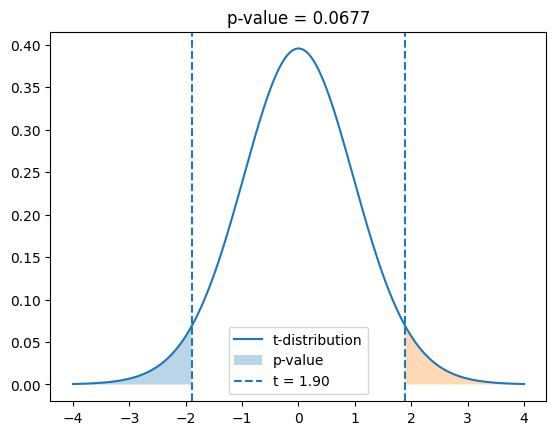

In [5]:
print("\n=== p-VALUE VISUALIZATION ===")

x = np.linspace(-4, 4, 500)
df = n - 1
t_dist = stats.t.pdf(x, df)

plt.figure()
plt.plot(x, t_dist, label="t-distribution")

# Shade p-value region
mask_left = x <= -abs(t_stat)
mask_right = x >= abs(t_stat)

plt.fill_between(x[mask_left], t_dist[mask_left], alpha=0.3, label="p-value")
plt.fill_between(x[mask_right], t_dist[mask_right], alpha=0.3)

plt.axvline(t_stat, linestyle="--", label=f"t = {t_stat:.2f}")
plt.axvline(-t_stat, linestyle="--")

plt.title(f"p-value = {p_value:.4f}")
plt.legend()

In [6]:
print("\n=== FALSE POSITIVE RATE ===")

count = 0
trials = 1000

for _ in range(trials):
    data = np.random.normal(0, 1, size=30)  # H0 true
    _, p = stats.ttest_1samp(data, 0)
    if p < 0.05:
        count += 1

print("False positive rate (~0.05 expected):", count / trials)


=== FALSE POSITIVE RATE ===
False positive rate (~0.05 expected): 0.052


In [7]:
print("\n=== A/B TEST ===")

n_A = n_B = 1000
p_A, p_B = 0.10, 0.14

A = np.random.binomial(1, p_A, n_A)
B = np.random.binomial(1, p_B, n_B)

p_hat_A = np.mean(A)
p_hat_B = np.mean(B)

print("Conversion rate A:", p_hat_A)
print("Conversion rate B:", p_hat_B)

# Z-test for proportions
p_pool = (np.sum(A) + np.sum(B)) / (n_A + n_B)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))

z_stat = (p_hat_B - p_hat_A) / se
p_val_ab = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("Z-statistic:", z_stat)
print("p-value:", p_val_ab)


=== A/B TEST ===
Conversion rate A: 0.114
Conversion rate B: 0.135
Z-statistic: 1.4223011001852313
p-value: 0.1549388596534973


In [8]:
print("\n=== SAMPLE SIZE EFFECT ===")

for n in [100, 1000, 10000]:
    A = np.random.binomial(1, 0.10, n)
    B = np.random.binomial(1, 0.11, n)

    pA = np.mean(A)
    pB = np.mean(B)

    p_pool = (np.sum(A) + np.sum(B)) / (2*n)
    se = np.sqrt(p_pool * (1 - p_pool) * (2/n))

    z = (pB - pA) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))

    print(f"n={n}, difference={pB-pA:.4f}, p-value={p_val:.6f}")

plt.show()


=== SAMPLE SIZE EFFECT ===
n=100, difference=-0.0900, p-value=0.078669
n=1000, difference=-0.0070, p-value=0.608880
n=10000, difference=0.0096, p-value=0.025531


With enough data, even tiny differences become statistically significant.